# **Finger Sign Detection with CNN**

#### 1. **Project Overview**

Sign language plays a crucial role in communication for the hearing-impaired community.

In this project, we build a **Convolutional Neural Network (CNN)** to classify hand sign images into **6 different sign classes** using the **Signs Detection Dataset**.

**Key Objectives:**
- Understand image-based classification
- Build an end-to-end deep learning pipeline
- Train and evaluate a CNN model
- Visualize predictions and performance

#### 2. **Problem Statement**

Hand sign recognition from images is challenging because hands can appear in different positions, lighting can change, and backgrounds may vary.

This project builds a CNN model that can learn visual patterns and correctly identify each hand sign.

#### 3. **Dataset Information**

- **Dataset:** Signs Detection Dataset
- **Source:** Kaggle
- **Image Size:** 64 × 64 RGB
- **Classes:** 6 hand sign categories

**Dataset Link:**  
[Signs Detection Dataset on Kaggle](https://www.kaggle.com/datasets/maneesh99/signs-detection-dataset)

#### 4. **Workflow**

The project follows this step-by-step workflow:

1. Dataset download and setup
2. Data loading and inspection
3. Image visualization
4. Data preprocessing
5. CNN model design
6. Model training
7. Performance evaluation
8. Result visualization
9. Final conclusions

#### 5. **Data Loading & Inspection**

- Load the dataset from HDF5 files using `h5py`
- Keep training and test sets separate
- Check shapes to ensure correct loading

#### 6. **Data Visualization**

- Display sample images and a grid of multiple images
- Verify labels and observe variations in hand signs, lighting, and backgrounds

#### 7. **Data Preprocessing**

- Convert images to NumPy arrays
- Normalize pixel values to `[0,1]`
- One-hot encode labels for model training

#### 8. **Model Architecture**

- Build a CNN with convolution, max-pooling, dense, and dropout layers
- Convolution layers extract features
- Dense layers classify images
- Dropout layers prevent overfitting

#### 9. **Model Summary**

- Show layer-wise summary
- Use `model.summary()` to visualize output shapes and number of parameters

#### 10. **Model Training**

- Train with Adam optimizer, categorical cross-entropy loss, and accuracy metric
- Track performance on validation data

#### 11. **Training Curves**

- Plot training and validation accuracy
- Plot training and validation loss
- Check learning progress and overfitting

#### 12. **Model Evaluation**

- Evaluate on test set
- Report test accuracy and loss

#### 13. **Classification Report**

- Display precision, recall, and F1-score for each class
- Analyze per-class performance

#### 14. **Confusion Matrix**

- Plot confusion matrix
- Identify correct vs incorrect predictions

#### 15. **Prediction Visualization**

- Show random test images
- Display actual vs predicted labels
- Inspect model predictions visually

#### 16. **Conclusion**

- Sccessfully built a **CNN-based sign language classifier**
- CNN effectively classifies hand signs
- Achieved strong accuracy on unseen test data
- Demonstrated full **industry-style ML workflow**

## **Environment Setup & Dataset Download**

In [8]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [9]:
!kaggle datasets download -d maneesh99/signs-detection-dataset


Dataset URL: https://www.kaggle.com/datasets/maneesh99/signs-detection-dataset
License(s): CC0-1.0
  0% 0.00/8.88M [00:00<?, ?B/s]
100% 8.88M/8.88M [00:00<00:00, 1.73GB/s]


In [10]:
!unzip signs-detection-dataset.zip -d signs_dataset


Archive:  signs-detection-dataset.zip
  inflating: signs_dataset/Signs_Data_Testing.h5  
  inflating: signs_dataset/Signs_Data_Training.h5  


## **Import Required Libraries**

In [34]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import h5py
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report



##  **Loading the Dataset**

In [12]:
train_data = h5py.File('/content/signs_dataset/Signs_Data_Training.h5')
test_data = h5py.File('/content/signs_dataset/Signs_Data_Testing.h5')

In [ ]:
# train_data.keys() , test_data.keys()

In [13]:

X_train = train_data['train_set_x']
y_train = train_data['train_set_y']
X_test = test_data['test_set_x']
y_test = test_data['test_set_y']

print(f"Train Shape: {X_train.shape}, {y_train.shape}")
print(f"Test Shape: {X_test.shape}, {y_test.shape}")

Train Shape: (1080, 64, 64, 3), (1080,)
Test Shape: (120, 64, 64, 3), (120,)


## **Visualizing**

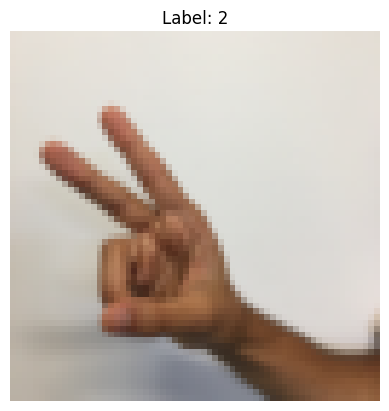

In [14]:
# visualize the image


index = 6
image = X_train[index]
label = y_train[index]

# Show the image
plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

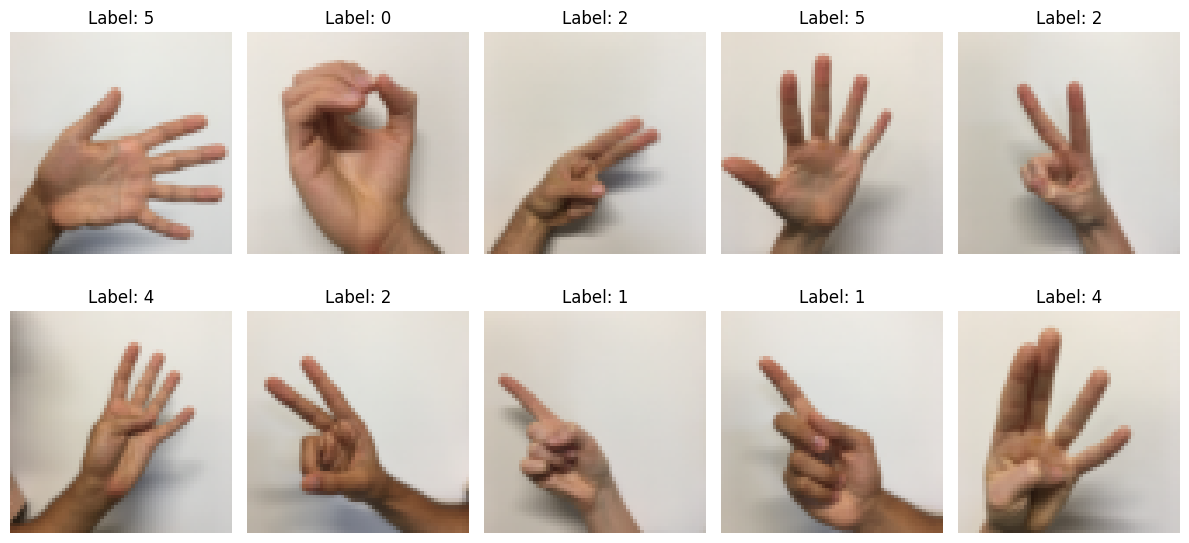

In [15]:
# visualizing top 10 training images

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_train[i])
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()



 ## **Data Preprocessing**

In [16]:
# converting it into numpy array & normalize


X_train = np.array(X_train) / 255.0
X_test = np.array(X_test) / 255.0

y_train = to_categorical(np.array(y_train))
y_test = to_categorical(np.array(y_test))

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (1080, 64, 64, 3)
Test Shape: (120, 64, 64, 3)


## **CNN Model Architecture**

In [17]:
#   Building the model


model = Sequential()


model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(64,64,3)))
#model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding ='valid'))

model.add(Conv2D(64, kernel_size=(3,3),padding='valid', activation='relu'))
#model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding ='valid'))


model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
#model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding ='valid'))


model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,734 (2.65 MB)

 Trainable params: 693,734 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:

# model summary table
model_summary = []

for layer in model.layers:
    model_summary.append({
        "Layer Name": layer.name,
        "Layer Type": layer.__class__.__name__,
        "Output Shape": layer.output.shape,
        "Parameters": layer.count_params()
    })

model_summary_df = pd.DataFrame(model_summary)

model_summary_df


,Layer Name,Layer Type,Output Shape,Parameters
0,conv2d,Conv2D,"(None, 62, 62, 32)",896
1,max_pooling2d,MaxPooling2D,"(None, 31, 31, 32)",0
2,conv2d_1,Conv2D,"(None, 29, 29, 64)",18496
3,max_pooling2d_1,MaxPooling2D,"(None, 14, 14, 64)",0
4,conv2d_2,Conv2D,"(None, 12, 12, 128)",73856
5,max_pooling2d_2,MaxPooling2D,"(None, 6, 6, 128)",0
6,flatten,Flatten,"(None, 4608)",0
7,dense,Dense,"(None, 128)",589952
8,dropout,Dropout,"(None, 128)",0
9,dense_1,Dense,"(None, 64)",8256


##  **Model Training**

In [22]:
model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics = ['accuracy'])

In [23]:
history = model.fit(X_train, y_train, batch_size=64, epochs=70, validation_data=(X_test, y_test))

Epoch 1/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 364ms/step - accuracy: 0.1630 - loss: 1.8013 - val_accuracy: 0.2000 - val_loss: 1.7899
Epoch 2/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1992 - loss: 1.7878 - val_accuracy: 0.1667 - val_loss: 1.7841
Epoch 3/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2373 - loss: 1.7642 - val_accuracy: 0.3667 - val_loss: 1.6467
Epoch 4/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3338 - loss: 1.5850 - val_accuracy: 0.5583 - val_loss: 1.3798
Epoch 5/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4405 - loss: 1.4186 - val_accuracy: 0.6083 - val_loss: 1.2003
Epoch 6/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5696 - loss: 1.2100 - val_accuracy: 0.6917 - val_loss: 0.9373
Epoch 7/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6336 - loss: 0.9532 - val_accuracy: 0.7417 - val_loss: 0.7331
Epoch 8/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6650 - loss: 0.8320 - val_accuracy: 0.7667 -

## **Model Performance Visualization**

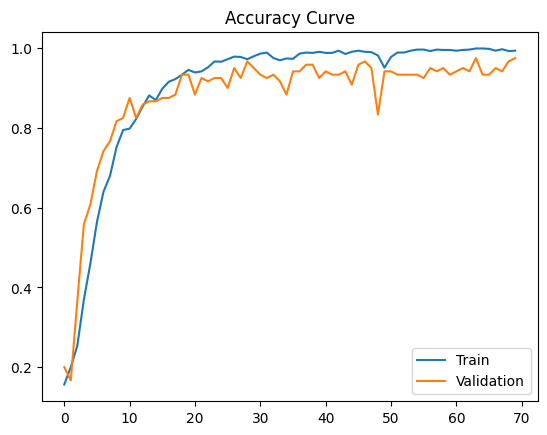

In [26]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy Curve")
plt.legend()
plt.show()




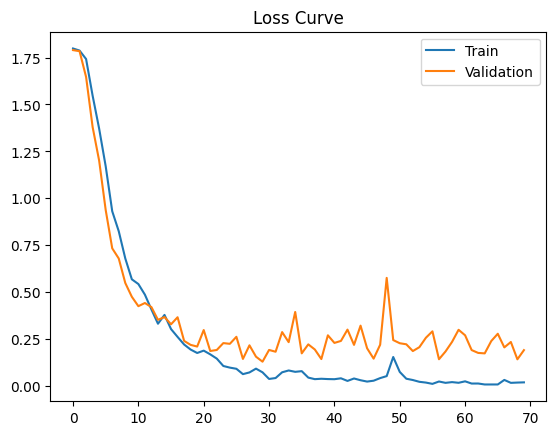

In [27]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss Curve")
plt.legend()
plt.show()




In [28]:
model.save('signs_cnn_model.keras')

## **Model Evaluation**

In [29]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_acc}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.9775 - loss: 0.1686
Test Loss: 0.19024772942066193
Test Accuracy: 0.9750000238418579


### **Classification Report**

In [32]:

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)


report = classification_report(y_true, y_pred_classes)
print(report)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.95      0.95      0.95        20
           2       0.95      0.95      0.95        20
           3       0.95      1.00      0.98        20
           4       1.00      0.95      0.97        20
           5       1.00      1.00      1.00        20

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



### **Confusion Matrix**

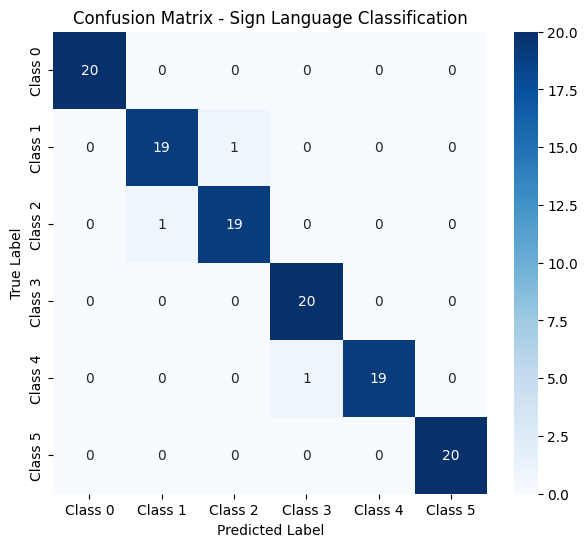

In [35]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"Class {i}" for i in range(6)],
    yticklabels=[f"Class {i}" for i in range(6)]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Sign Language Classification")
plt.show()

##  **Prediction Visualization**

In [36]:
# Select 10 random test images

indices = np.random.choice(len(X_test), 10 , replace = False)

In [37]:
indices

array([119,  11,  16,  25,   8,  26, 102,  93,   4,  70])

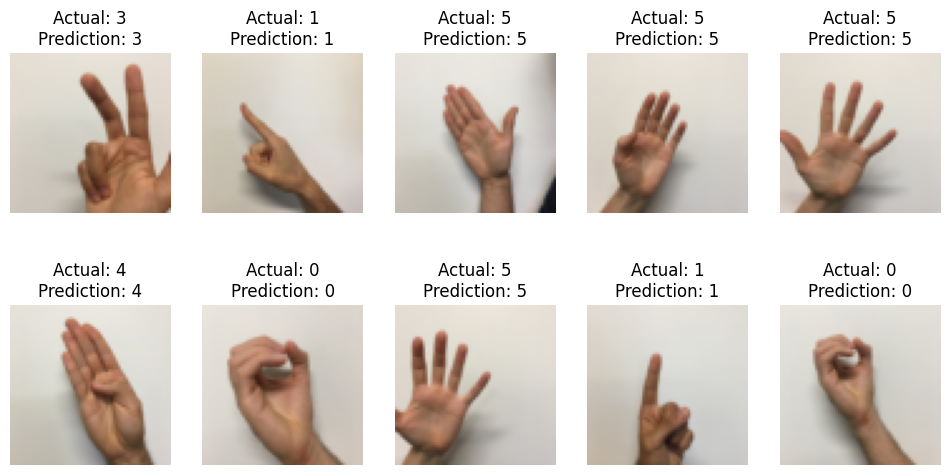

In [38]:

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, idx in enumerate(indices):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx].squeeze(), cmap="gray") # If grayscale cmap="gray"
    ax.set_title(f"Actual: {np.argmax(y_test[idx])}\nPrediction: {y_pred_classes[idx]}")
    ax.axis("off")

plt.show()


## **Final Conclusion**


- Successfully built a **CNN-based sign language classifier**
- CNN effectively classifies hand signs
- Achieved strong accuracy on unseen test data
- Demonstrated full **industry-style ML workflow**